In [36]:
# 1. Locate the project root and activate the environment
const PROJECT_ROOT = let
    dir = @__DIR__
    while !isfile(joinpath(dir, "Project.toml")) && dir != dirname(dir)
        dir = dirname(dir)
    end
    dir
end

using Pkg
Pkg.activate("..") # or PROJECT_ROOT

# 2. Include the simulation sources (automatically imports required packages from utils.jl)
include(joinpath(PROJECT_ROOT, "src", "simulation.jl"))
include(joinpath(PROJECT_ROOT, "src", "simulation_liquid.jl"))

using Random, NPZ, Plots

  Activating project at `/data/UNIVERSITA/PhD/PROJECTS/CancerEvo`
  Activating project at `/data/UNIVERSITA/PhD/PROJECTS/CancerEvo`
  Activating project at `/data/UNIVERSITA/PhD/PROJECTS/CancerEvo`


In [6]:
# ==========================================
# PART 1: Run Solid Tumor Simulation
# ==========================================

# Load parameters for the Solid Case
include(joinpath(PROJECT_ROOT, "scripts", "solid", "parameters.jl"))

println("--- Starting Solid Tumor Simulation ---")
println("L = $L, steps = $n_steps, N_CHR = $N_CHR")

Random.seed!(time_ns())

--- Starting Solid Tumor Simulation ---
L = 200, steps = 2500, N_CHR = 2


TaskLocalRNG()

In [33]:
# Initialize tissue
tiss_solid = OptimizedTissue(L, N_I, N_O, N_S, N_M, N_HK, 
                             mu0, 0.012, 
                             r0, 0.008, rmax, 
                             0.0, N_CHR)


OptimizedTissue(200, 45, Int8[0, 0, 0, 0, 0, 0, 0, 0, 0, 0  …  0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.15, 0.15, 0.15, 0.15, 0.15, 0.15, 0.15, 0.15, 0.15, 0.15  …  0.15, 0.15, 0.15, 0.15, 0.15, 0.15, 0.15, 0.15, 0.15, 0.15], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], UInt64[0x0000000000000000 0x0000000000000000 … 0x0000000000000000 0x0000000000000000; 0x0000000000000000 0x0000000000000000 … 0x0000000000000000 0x0000000000000000; … ; 0x0000000000000000 0x0000000000000000 … 0x0000000000000000 0x0000000000000000; 0x0000000000000000 0x0000000000000000 … 0x0000000000000000 0x0000000000000000], Int8[2, 2, 2, 2, 2, 2, 2, 2, 2, 2  …  2, 2, 2, 2, 2, 2, 2, 2, 2, 2], 0.0, 0.012, 0.15, 0.008, 0.3, 0.0, 0x00000000000003ff, 0x00000000000ffc00, 0x000000003ff00000, 0x00000007c0000000, 0x00001ff800000000, [[201, 2, 202], [1, 201, 202, 3, 203], 

In [34]:
println("Applying initial perturbation...")
perturb_optimized!(tiss_solid, 0.005, pert_chrs)

println("Running simulation loop with missegregation mechanism: ", misseg_type)
results_solid = simulation_optimized(tiss_solid, N_CHR, n_steps, n_it_store, false, limit, 0.0, misseg_type)

# Save results
output_dir_solid = joinpath(PROJECT_ROOT, "data", "simulations")
if !isdir(output_dir_solid); mkpath(output_dir_solid); end

output_file_solid = joinpath(output_dir_solid, "results.npz")
println("Saving solid results to $output_file_solid ...")

results_dict_solid = Dict(
    "mu" => results_solid.mu,
    "r" => results_solid.r,
    "m" => results_solid.m,
    "n_chrs" => results_solid.n_chrs,
    "tumor_density" => results_solid.tumor_density,
    "death_density" => results_solid.dcells_density,
    "outcome_code" => [results_solid.state == "Health" ? 0 : results_solid.state == "Tumor" ? 1 : 2]
)
for (i, type) in enumerate(["I", "O", "S", "M", "HK"])
    results_dict_solid["mut_$(type)"] = results_solid.muts[i]
    results_dict_solid["act_$(type)"] = results_solid.activations[i]
end
println("Solid simulation finished. Outcome: ", results_solid.state)

Applying initial perturbation...
Running simulation loop with missegregation mechanism: whole
Over
Saving solid results to /data/UNIVERSITA/PhD/PROJECTS/CancerEvo/data/simulations/results.npz ...
Solid simulation finished. Outcome: Tumor_Max


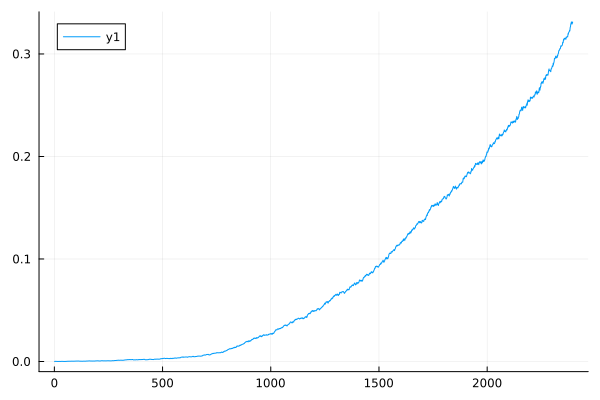

In [35]:
plot((results_dict_solid["tumor_density"]))
#plot!(results_dict_solid["death_density"])

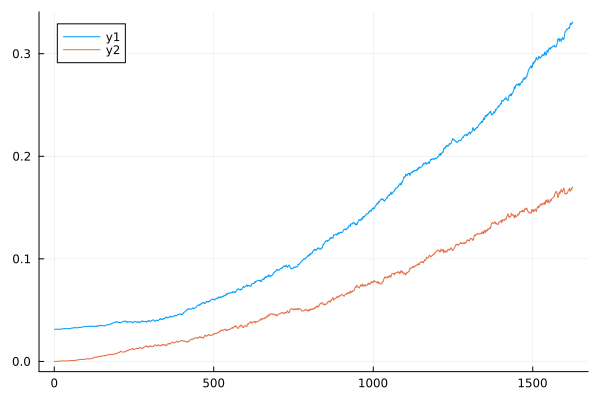

In [ ]:
plot((results_dict_solid["tumor_density"]))
plot!(results_dict_solid["death_density"])

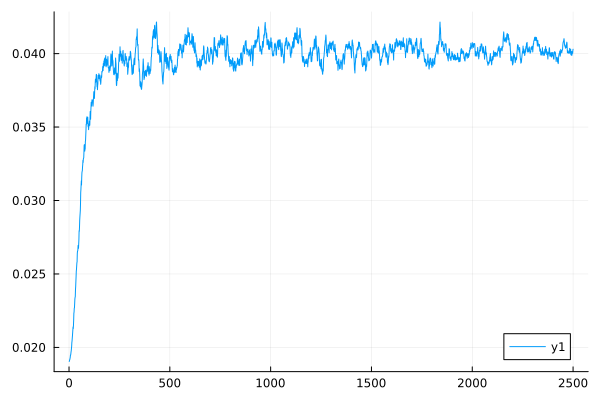

In [261]:
plot(results_dict_solid["mu"])

In [262]:
tiss_solid

# 1. Get the mutated I gene level (0 to N_I) for each cancer cell
i_levels = [count_ones(reduce(&, tiss_solid.chromosomes[1:tiss_solid.n_chrs[idx], idx]) & tiss_solid.mask_I) for idx in findall(tiss_solid.state .== 1)]
# 2. Compute the fraction for each level k from 0 to N_I
fractions_solid = [count(==(k), i_levels) / length(i_levels) for k in 0:count_ones(tiss_solid.mask_I)]

11-element Vector{Float64}:
 0.0
 0.4195162635529608
 0.27773144286905754
 0.1586043925493467
 0.08354184042257437
 0.03753127606338615
 0.015151515151515152
 0.0061162079510703364
 0.0016680567139282735
 0.00013900472616068947
 0.0

In [37]:
# ==========================================
# PART 2: Run Liquid Tumor Simulation
# ==========================================

# Load parameters for the Liquid Case (overwrites shared parameters)
include(joinpath(PROJECT_ROOT, "scripts", "liquid", "parameters_liquid.jl"))

println("\n--- Starting Liquid Tumor Simulation ---")
println("L = $L, steps = $n_steps, N_CHR = $N_CHR")

Random.seed!(time_ns())


--- Starting Liquid Tumor Simulation ---
L = 200, steps = 2500, N_CHR = 2


TaskLocalRNG()

In [93]:
# Initialize tissue (Moran process operates on L*L well-mixed cells)
tiss_liquid = LiquidTissue(200 * 200, N_I, N_O, N_S, N_M, N_HK, 
                           mu0, 0.023, 
                           r0, 0.08, 2*r0, 
                           dm, N_CHR)

LiquidTissue(40000, 45, Int8[0, 0, 0, 0, 0, 0, 0, 0, 0, 0  …  0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.15, 0.15, 0.15, 0.15, 0.15, 0.15, 0.15, 0.15, 0.15, 0.15  …  0.15, 0.15, 0.15, 0.15, 0.15, 0.15, 0.15, 0.15, 0.15, 0.15], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], UInt64[0x0000000000000000 0x0000000000000000 … 0x0000000000000000 0x0000000000000000; 0x0000000000000000 0x0000000000000000 … 0x0000000000000000 0x0000000000000000; … ; 0x0000000000000000 0x0000000000000000 … 0x0000000000000000 0x0000000000000000; 0x0000000000000000 0x0000000000000000 … 0x0000000000000000 0x0000000000000000], Int8[2, 2, 2, 2, 2, 2, 2, 2, 2, 2  …  2, 2, 2, 2, 2, 2, 2, 2, 2, 2], 0.0, 0.023, 0.15, 0.08, 0.3, 0.0, 0x00000000000003ff, 0x00000000000ffc00, 0x000000003ff00000, 0x00000007c0000000, 0x00001ff800000000)

In [94]:
Random.seed!(time_ns())

println("Seeding $n_seed cancer cells at random positions (liquid perturbation)...")
perturb_liquid!(tiss_liquid, 10, pert_chrs)

println("Running simulation loop with missegregation mechanism: ", misseg_type)
results_liquid = simulation_liquid(tiss_liquid, N_CHR, n_steps, n_it_store, false, 0.99, 0.0, misseg_type)

# Save results
output_dir_liquid = joinpath(PROJECT_ROOT, "data", "simulations_liquid")
if !isdir(output_dir_liquid); mkpath(output_dir_liquid); end

output_file_liquid = joinpath(output_dir_liquid, "results.npz")
println("Saving liquid results to $output_file_liquid ...")

results_dict_liquid = Dict(
    "mu"            => results_liquid.mu,
    "r"             => results_liquid.r,
    "m"             => results_liquid.m,
    "n_chrs"        => results_liquid.n_chrs,
    "tumor_density" => results_liquid.tumor_density,
    "death_density" => results_liquid.dcells_density,
    "outcome_code"  => [results_liquid.state == "Health"    ? 0 :
                        results_liquid.state == "Tumor_Max" ? 1 :
                        results_liquid.state == "Tumor_Min" ? 3 : 2]
)
for (i, type) in enumerate(["I", "O", "S", "M", "HK"])
    results_dict_liquid["mut_$(type)"] = results_liquid.muts[i]
    results_dict_liquid["act_$(type)"] = results_liquid.activations[i]
end
println("Liquid simulation finished. Outcome: ", results_liquid.state)


Seeding 10 cancer cells at random positions (liquid perturbation)...
Running simulation loop with missegregation mechanism: whole
Completed steps
Saving liquid results to /data/UNIVERSITA/PhD/PROJECTS/CancerEvo/data/simulations_liquid/results.npz ...
Liquid simulation finished. Outcome: Done


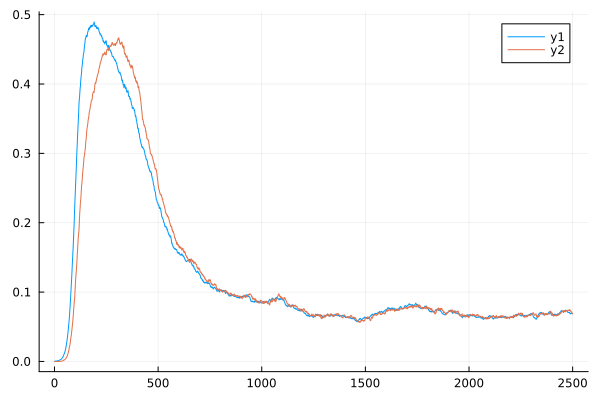

In [95]:
plot(results_dict_liquid["tumor_density"])
plot!(results_dict_liquid["death_density"])


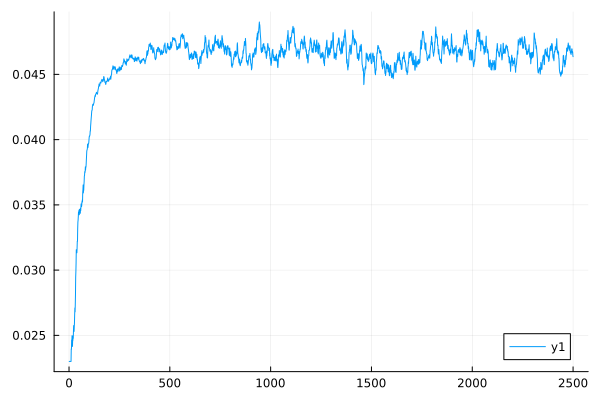

In [96]:
plot(results_dict_liquid["mu"])

In [75]:
tiss_liquid

# 1. Get the mutated I gene level (0 to N_I) for each cancer cell
i_levels = [count_ones(reduce(&, tiss_liquid.chromosomes[1:tiss_liquid.n_chrs[idx], idx]) & tiss_liquid.mask_I) for idx in findall(tiss_liquid.state .== 1)]
# 2. Compute the fraction for each level k from 0 to N_I
fractions_liquid = [count(==(k), i_levels) / length(i_levels) for k in 0:count_ones(tiss_liquid.mask_I)]

11-element Vector{Float64}:
 0.0
 0.5550288540807914
 0.2683429513602638
 0.10449299258037922
 0.04843363561417972
 0.01628194558944765
 0.0053586150041220115
 0.001030502885408079
 0.001030502885408079
 0.0
 0.0

In [69]:
sum(fractions_liquid .* [0,1,2,3,4,5,6,7,8,9,10])*0.019

0.04025423728813558

In [45]:
sum(fractions_solid .* [0,1,2,3,4,5,6,7,8,9,10])*0.019

LoadError: UndefVarError: `fractions_solid` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

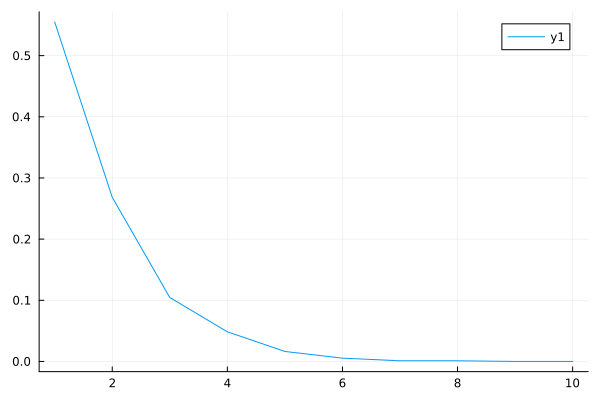

In [76]:
plot(fractions_liquid[2:11])